# GRUPO 43 — Proyecto Aprendizaje de Máquina 2026-20
## Integrantes: 
* David Alejandro Zambrano - 202321948
* Juan Felipe Ochoa - 202320053

# Clasificación de sentimiento en reseñas de productos en español

**Parte 1: Machine Learning clásico — Entrega 1 (solución inicial)**

En este notebook presentamos nuestra primera solución para la competencia de Kaggle del curso. La tarea consiste en predecir, a partir del texto de una reseña, si la opinión global del cliente es `negativo`, `neutral` o `positivo`.

La solución usa únicamente herramientas vistas en la primera parte del curso:

- Representación del texto con **bolsa de palabras (BoW)**, **TF‑IDF** y **n‑gramas**.
- Modelos de clasificación de **scikit-learn**: Naive Bayes multinomial, regresión logística y árbol de decisión.
- Validación con partición *hold-out* estratificada y búsqueda de hiperparámetros con validación cruzada (`GridSearchCV`).

Esta es deliberadamente una **primera versión**: un pipeline simple, reproducible y bien validado que sirve como punto de partida. Al final del notebook dejamos identificadas las limitaciones y las mejoras que exploraremos en los siguientes envíos.

## Resumen de lo que hicimos

| Paso | Qué se hizo | Por qué se hizo |
|---|---|---|
| 1. Carga y verificación | Se cargaron `data/train.csv` y `data/eval.csv` y se revisaron columnas, nulos, duplicados y clases. | Confirmar que el notebook trabaja con el formato correcto de la competencia. |
| 2. Exploración | Distribución de clases, longitud de reseñas, ejemplos y uso de tildes. | Entender el problema antes de modelar y decidir la limpieza. |
| 3. Preprocesamiento | Minúsculas, eliminación de tildes y de caracteres no alfabéticos. **No** se eliminan *stop words*. | Las palabras como `no`, `pero`, `aunque` cambian el sentimiento. |
| 4. Comparación de modelos base | BoW + Naive Bayes, TF‑IDF + regresión logística, TF‑IDF + árbol de decisión. | Tener una referencia y escoger la familia de modelo más prometedora. |
| 5. Ajuste de hiperparámetros | `GridSearchCV` (5 *folds*, métrica F1 macro) sobre el pipeline TF‑IDF + regresión logística. | Seleccionar `C` y el rango de n‑gramas de forma objetiva. |
| 6. Evaluación | Reporte de clasificación y matriz de confusión sobre validación. | Medir el desempeño en datos no vistos. |
| 7. Análisis de errores | Revisión de reseñas mal clasificadas. | Entender qué no captura la bolsa de palabras y orientar las mejoras. |
| 8. Modelo final y envío | Reentrenamiento con todo `train.csv`, predicción de `eval.csv`, `submission.csv` y modelo guardado con `joblib`. | Generar los entregables replicables. |

## Reglas que seguimos

- `train.csv` se usa para entrenamiento y validación local.
- `eval.csv` **no** se usa para entrenar, ajustar hiperparámetros ni escoger modelos; solo se usa al final para generar la *submission*.
- No se usan redes neuronales, transformers ni *embeddings* preentrenados. Toda la representación del texto es BoW / TF‑IDF / n‑gramas y todos los clasificadores son de scikit-learn.
- Todas las semillas aleatorias están fijas (`RANDOM_STATE = 42`) para que los resultados sean replicables.

## 1. Preparación del entorno

In [ ]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
DATA_DIR = Path("../data")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

## 2. Carga de datos y verificación del formato

Los datos de la competencia están en la carpeta `data/`:

- `train.csv`: 12.000 reseñas con `id`, `text` y `label`.
- `eval.csv`: 3.000 reseñas con `id` y `text` (sin etiqueta).
- `sample_submission.csv`: formato esperado del envío (`id,answer`).

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train_df.shape, list(train_df.columns))
print("eval: ", eval_df.shape, list(eval_df.columns))
print("sample_submission:", sample_sub.shape, list(sample_sub.columns))
print()
print("Nulos train:", train_df.isna().sum().to_dict())
print("Nulos eval: ", eval_df.isna().sum().to_dict())
print("Textos duplicados en train:", train_df["text"].duplicated().sum())
print("Textos de eval que aparecen en train:", eval_df["text"].isin(train_df["text"]).sum())

train: (12000, 3) ['id', 'text', 'label']
eval:  (3000, 2) ['id', 'text']
sample_submission: (3000, 2) ['id', 'answer']

Nulos train: {'id': 0, 'text': 0, 'label': 0}
Nulos eval:  {'id': 0, 'text': 0}
Textos duplicados en train: 0
Textos de eval que aparecen en train: 0


In [3]:
assert {"id", "text", "label"}.issubset(train_df.columns)
assert {"id", "text"}.issubset(eval_df.columns)
assert set(train_df["label"].unique()) == {"negativo", "neutral", "positivo"}
assert eval_df["id"].is_unique
assert (eval_df["id"].values == sample_sub["id"].values).all(), "Los ids de eval y sample_submission deben coincidir"
print("Formato verificado correctamente.")

Formato verificado correctamente.


No hay nulos ni duplicados, y ningún texto de `eval.csv` aparece en `train.csv`, así que no hay fuga trivial de información. Los `id` de `eval.csv` coinciden con los de `sample_submission.csv`, en el mismo orden.

## 3. Exploración de los datos

### 3.1 Distribución de clases y longitud de las reseñas

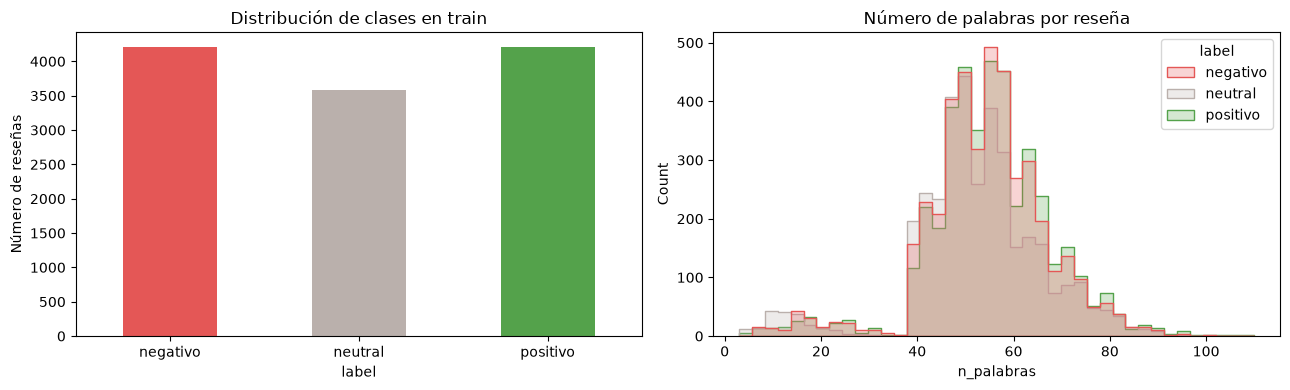

,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = ["negativo", "neutral", "positivo"]
train_df["label"].value_counts().reindex(order).plot(kind="bar", ax=axes[0], color=["#E45756", "#BAB0AC", "#54A24B"])
axes[0].set_title("Distribución de clases en train")
axes[0].set_ylabel("Número de reseñas")
axes[0].tick_params(axis="x", rotation=0)

train_df["n_palabras"] = train_df["text"].str.split().str.len()
sns.histplot(data=train_df, x="n_palabras", hue="label", hue_order=order, bins=40,
             element="step", ax=axes[1], palette=["#E45756", "#BAB0AC", "#54A24B"])
axes[1].set_title("Número de palabras por reseña")
plt.tight_layout()
plt.show()

display(train_df["label"].value_counts(normalize=True).reindex(order).round(3).to_frame("proporción"))
display(train_df.groupby("label")["n_palabras"].describe().round(1))

**Lecturas:**

- Las clases están razonablemente balanceadas (35 % negativo, 30 % neutral, 35 % positivo). No es necesario aplicar técnicas de balanceo; sí conviene reportar **F1 macro** además de *accuracy*, para no ocultar un mal desempeño en la clase `neutral`, que es la minoritaria.
- Las reseñas son cortas (alrededor de 54 palabras) y de longitud parecida entre clases, así que la longitud por sí sola no discrimina el sentimiento.

### 3.2 Ejemplos de reseñas

In [5]:
for label in order:
    print("=" * 100)
    print("CLASE:", label.upper())
    for t in train_df[train_df["label"] == label]["text"].sample(2, random_state=RANDOM_STATE):
        print("-", t)

CLASE: NEGATIVO
- La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.
- Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora.
CLASE: NEUTRAL
- Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que el jueves ya lo tenía en casa. Lo entregó la mensajería de siempre, el mismo señor que suele pasar por la cuadra, y me lo dejó en la recepción porque no estaba. La caja venía cerrada con su plástico. Trae garantía de seis meses según el papelito que venía adentro.
- Lo compré hace unas semanas por internet y 

Los ejemplos confirman lo que advierte el enunciado: muchas reseñas mezclan elogios y quejas, y el sentimiento global suele quedar determinado por la **parte final** de la reseña, después de conectores como *"aun así"*, *"al final de cuentas"* o *"pero"*. Las reseñas neutrales tienden a ser descriptivas (envío, empaque, uso) sin juicios fuertes.

Esto anticipa una limitación importante: la bolsa de palabras **pierde el orden** de las palabras. Una reseña que dice "bueno… pero malo" y otra que dice "malo… pero bueno" tienen casi la misma representación. Los n‑gramas recuperan solo algo de ese contexto local.

### 3.3 Uso de tildes

Al revisar `eval.csv` notamos reseñas escritas sin tildes (por ejemplo, *"llego"*, *"aplicacion"*). Medimos qué tan frecuente es esto en ambos conjuntos.

In [6]:
tiene_tilde = lambda s: s.str.contains(r"[áéíóúÁÉÍÓÚ]").mean()
print(f"Reseñas con al menos una tilde -> train: {tiene_tilde(train_df['text']):.1%} | eval: {tiene_tilde(eval_df['text']):.1%}")

Reseñas con al menos una tilde -> train: 67.8% | eval: 67.5%


Alrededor de un tercio de las reseñas, en ambos conjuntos, no tiene ninguna tilde. Si no normalizamos, `llegó` y `llego` serían dos tokens distintos y el vocabulario se fragmentaría. Por eso **eliminamos las tildes** en el preprocesamiento.

## 4. Preprocesamiento del texto

Siguiendo el pipeline de la práctica de procesamiento de textos (normalización → tokenización → *stop words* → *stemming*), tomamos estas decisiones:

| Paso | Decisión | Justificación |
|---|---|---|
| Minúsculas | Sí | `Excelente` y `excelente` deben ser el mismo token. |
| Quitar tildes | Sí | Un tercio de las reseñas no usa tildes; unificamos `llegó`/`llego`. |
| Quitar puntuación y números | Sí | En una bolsa de palabras no aportan al sentimiento. |
| Quitar *stop words* | **No** | La lista de *stop words* en español incluye `no`, `pero`, `muy`, `sin`, que son clave para el sentimiento ("no funciona", "pero se dañó"). |
| *Stemming* / lematización | No, en esta versión | Lo dejamos como experimento para siguientes envíos. |

In [7]:
def quitar_tildes(texto):
    texto = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in texto if not unicodedata.combining(c))

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = quitar_tildes(texto)
    texto = re.sub(r"[^a-zñ\s]", " ", texto)   # deja solo letras
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

train_df["text_clean"] = train_df["text"].map(limpiar_texto)
eval_df["text_clean"] = eval_df["text"].map(limpiar_texto)

ejemplo = train_df["text"].iloc[3]
print("Original:", ejemplo)
print("Limpio:  ", limpiar_texto(ejemplo))

Original: Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que necesitaba, la verdad. Lo probé el fin de semana mientras armaba el espacio donde lo iba a poner.
Limpio:   compre esto en linea y llego en unos tres dias a la casa venian varias unidades en el paquete revise todas una por una el ensamblaje termino siendo impreciso para lo que necesitaba la verdad lo probe el fin de semana mientras armaba el espacio donde lo iba a poner


## 5. Partición entrenamiento / validación

Separamos el 20 % de `train.csv` como conjunto de validación, de forma **estratificada** para conservar la proporción de clases. Este conjunto no se usa para ajustar hiperparámetros: la búsqueda se hace con validación cruzada sobre el 80 % restante, y la validación solo se usa para medir el desempeño final.

In [8]:
X = train_df["text_clean"]
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Entrenamiento:", X_train.shape[0], "| Validación:", X_val.shape[0])

Entrenamiento: 9600 | Validación: 2400


## 6. Comparación de modelos base

Probamos tres combinaciones de representación y clasificador, todas con hiperparámetros por defecto, para elegir una familia de modelo:

1. **BoW + Naive Bayes multinomial**: el clásico de clasificación de texto, rápido y con pocas suposiciones.
2. **TF‑IDF + regresión logística**: TF‑IDF baja el peso de las palabras que aparecen en todas las reseñas (por ejemplo, "llegó", "caja") y la regresión logística aprende un peso por término.
3. **TF‑IDF + árbol de decisión**: modelo no lineal visto en clase; sirve como contraste.

Usamos `Pipeline` para que el vectorizador se ajuste solo con los datos de entrenamiento y no haya fuga de información hacia validación.

In [9]:
modelos_base = {
    "BoW + Naive Bayes": Pipeline([
        ("vec", CountVectorizer()),
        ("clf", MultinomialNB()),
    ]),
    "TF-IDF + Regresión logística": Pipeline([
        ("vec", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "TF-IDF + Árbol de decisión": Pipeline([
        ("vec", TfidfVectorizer()),
        ("clf", DecisionTreeClassifier(max_depth=30, random_state=RANDOM_STATE)),
    ]),
}

resultados = []
for nombre, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_val)
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_val, pred),
        "f1_macro": f1_score(y_val, pred, average="macro"),
    })

resultados_base = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False).round(4)
display(resultados_base)

,modelo,accuracy,f1_macro
1,TF-IDF + Regresión logística,0.7383,0.7487
0,BoW + Naive Bayes,0.7108,0.7235
2,TF-IDF + Árbol de decisión,0.5808,0.5939


**Lectura:** la regresión logística sobre TF‑IDF obtiene el mejor F1 macro, Naive Bayes queda cerca y el árbol de decisión queda claramente por debajo. Un árbol parte el espacio usando una sola palabra a la vez, lo que funciona mal con miles de variables dispersas en las que cada palabra aporta un poco de evidencia. Los modelos lineales combinan la evidencia de todas las palabras a la vez.

Escogemos **TF‑IDF + regresión logística** como modelo de esta entrega y ajustamos sus hiperparámetros.

## 7. Ajuste de hiperparámetros con validación cruzada

Exploramos dos hiperparámetros:

- `ngram_range`: unigramas `(1,1)` o unigramas + bigramas `(1,2)`. Los bigramas capturan algo de contexto local como "no funciona", "muy bueno" o "aun asi".
- `C`: inverso de la fuerza de regularización (L2) de la regresión logística. Un `C` pequeño regulariza más (modelo más simple); un `C` grande ajusta más los datos y puede sobreajustar.

Usamos `GridSearchCV` con 5 *folds* estratificados y F1 macro como métrica de selección. `min_df=2` descarta términos que aparecen en una sola reseña, que casi siempre son ruido.

In [10]:
pipeline = Pipeline([
    ("vec", TfidfVectorizer(min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

param_grid = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipeline, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

cv_res = pd.DataFrame(grid.cv_results_)[[
    "param_vec__ngram_range", "param_clf__C", "mean_train_score", "mean_test_score", "std_test_score"
]].sort_values("mean_test_score", ascending=False).round(4)
display(cv_res)
print("Mejores hiperparámetros:", grid.best_params_)
print(f"F1 macro promedio en CV: {grid.best_score_:.4f}")

,param_vec__ngram_range,param_clf__C,mean_train_score,mean_test_score,std_test_score
4,"(1, 1)",10.0,0.8930,0.7490,0.0085
5,"(1, 2)",10.0,0.9969,0.7455,0.0130
2,"(1, 1)",1.0,0.8394,0.7399,0.0121
3,"(1, 2)",1.0,0.9259,0.7380,0.0178
1,"(1, 2)",0.1,0.8168,0.7132,0.0168
0,"(1, 1)",0.1,0.7731,0.7103,0.0125


Mejores hiperparámetros: {'clf__C': 10, 'vec__ngram_range': (1, 1)}
F1 macro promedio en CV: 0.7490


**Lectura de la tabla:**

- Con `C = 0.1` el modelo está **subajustado**: tanto el F1 de entrenamiento como el de validación cruzada son los más bajos de la tabla.
- Al subir `C`, el F1 de entrenamiento se acerca a 1, mientras que el de validación cruzada apenas mejora. La brecha creciente entre ambos indica **sobreajuste**: el modelo memoriza reseñas de entrenamiento en lugar de generalizar. Es el mismo compromiso sesgo‑varianza visto en regularización (Ridge/Lasso).
- Contra lo que esperábamos, los **bigramas no mejoran** el resultado: con `C = 10` llevan el F1 de entrenamiento casi a 1 (más sobreajuste) sin ganancia en validación cruzada. El mejor modelo usa solo unigramas. Una hipótesis es que, con 9.600 reseñas, la mayoría de bigramas son poco frecuentes y agregan más ruido que señal. Esto queda pendiente de revisar con una regularización más fuerte o con `min_df` más alto.

## 8. Evaluación en el conjunto de validación

Accuracy validación: 0.7421
F1 macro validación: 0.7535

              precision    recall  f1-score   support

    negativo     0.6428    0.6275    0.6351       843
     neutral     0.9781    0.9986    0.9882       715
    positivo     0.6352    0.6390    0.6371       842

    accuracy                         0.7421      2400
   macro avg     0.7520    0.7550    0.7535      2400
weighted avg     0.7400    0.7421    0.7410      2400



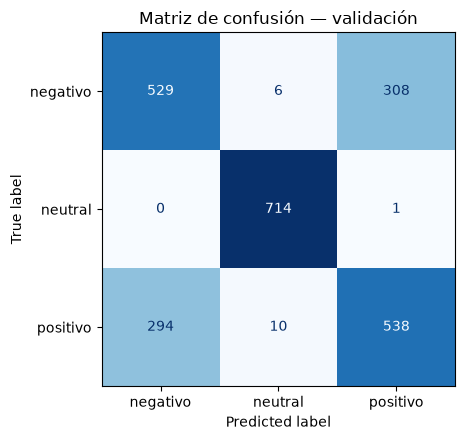

In [11]:
mejor_modelo = grid.best_estimator_
pred_val = mejor_modelo.predict(X_val)

print(f"Accuracy validación: {accuracy_score(y_val, pred_val):.4f}")
print(f"F1 macro validación: {f1_score(y_val, pred_val, average='macro'):.4f}")
print()
print(classification_report(y_val, pred_val, digits=4))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_val, pred_val, labels=order, cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión — validación")
plt.tight_layout()
plt.show()

**Lectura:** la clase `neutral` queda prácticamente resuelta (F1 ≈ 0.99), porque las reseñas descriptivas usan un vocabulario muy distinto al de las que emiten juicios. **Casi todos los errores son confusiones entre `positivo` y `negativo`**, donde el F1 cae a ≈ 0.64. Esto es coherente con la naturaleza del problema: esas reseñas contienen a la vez palabras positivas y negativas, y lo que decide la clase es cuál juicio queda al final.

### 8.1 Interpretación: palabras con más peso por clase

Como la regresión logística es un modelo lineal, podemos revisar los coeficientes para ver qué términos empujan hacia cada clase.

In [12]:
vec = mejor_modelo.named_steps["vec"]
clf = mejor_modelo.named_steps["clf"]
vocab = np.array(vec.get_feature_names_out())

top = {}
for i, clase in enumerate(clf.classes_):
    idx = np.argsort(clf.coef_[i])[::-1][:15]
    top[clase] = vocab[idx]
display(pd.DataFrame(top))

,negativo,neutral,positivo
0,mal,color,sola
1,regalado,voltios,acierto
2,defraudo,tamanos,feliz
3,vale,trae,estrellas
4,decepciono,todavia,pena
5,harto,unidades,verdad
6,resulto,litio,respondio
7,error,usb,supero
8,debajo,kilo,maravilla
9,estrella,contar,encantado


Los términos más importantes tienen sentido: adjetivos de juicio para `positivo` y `negativo`, y palabras de logística o descripción (envío, caja, color) para `neutral`. Esto indica que el modelo aprende señal real y no artefactos del conjunto de datos.

## 9. Análisis de errores

In [13]:
errores = pd.DataFrame({"texto": train_df.loc[X_val.index, "text"], "real": y_val, "pred": pred_val})
errores = errores[errores["real"] != errores["pred"]]
print(f"Errores: {len(errores)} de {len(y_val)}")
display(pd.crosstab(errores["real"], errores["pred"]))
for _, r in errores[errores["real"].isin(["positivo", "negativo"])].sample(4, random_state=RANDOM_STATE).iterrows():
    print("-" * 100)
    print(f"REAL: {r['real']} | PREDICHO: {r['pred']}")
    print(r["texto"])

Errores: 619 de 2400


pred,negativo,neutral,positivo
real,,,
negativo,0,6,308
neutral,0,0,1
positivo,294,10,0


----------------------------------------------------------------------------------------------------
REAL: positivo | PREDICHO: negativo
Compre esto a mediados de ano porque lo necesitaba para el trabajo, llego en unos cinco dias a casaa. El material me resulto olvidable desde el primer dia, la verdad. Lo uso diario en el escritorio junto a la compu, nada del oro mundo. Al final la ergonomia luce fiable hasta ahora.
----------------------------------------------------------------------------------------------------
REAL: negativo | PREDICHO: positivo
Se lo compre a un familiar despues de varias semanas de estar buscandolo, llego en tres dias a la casa de el. El cable funciona de maravilla. La uso a diario para cargar el celular en la oficina. De paso, el boton de encendido se dano antes de lo que esperaba, como en un mes. Sopesalo tu mismo.
----------------------------------------------------------------------------------------------------
REAL: negativo | PREDICHO: positivo
Le compre 

En los errores aparece el patrón esperado: la reseña contiene un elogio y una queja, y la bolsa de palabras no sabe cuál de las dos frases es la conclusión. Por ejemplo, ante *"el soporte fue incumplidor… al final de cuentas, la imagen se mantuvo decente"*, el modelo ve una palabra negativa y una positiva con peso parecido, aunque la clase real la decide la última oración.

Esta es la principal limitación de BoW/TF‑IDF señalada en el enunciado, y orienta las mejoras de las siguientes versiones (sección 11).

## 10. Modelo final, predicción sobre `eval.csv` y guardado

Reentrenamos el pipeline con los mejores hiperparámetros sobre **todo** `train.csv`, para aprovechar el 100 % de los datos etiquetados. Luego predecimos `eval.csv` y generamos el archivo de envío con el formato de `sample_submission.csv` (`id,answer`).

In [16]:
modelo_final = Pipeline([
    ("vec", TfidfVectorizer(min_df=2, sublinear_tf=True, ngram_range=grid.best_params_["vec__ngram_range"])),
    ("clf", LogisticRegression(C=grid.best_params_["clf__C"], max_iter=3000, random_state=RANDOM_STATE)),
])
modelo_final.fit(train_df["text_clean"], train_df["label"])

submission = pd.DataFrame({
    "id": eval_df["id"],
    "answer": modelo_final.predict(eval_df["text_clean"]),
})

assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert submission["answer"].isin(order).all()

submission.to_csv("submission.csv", index=False)
print(submission.head())
print()
print(submission["answer"].value_counts(normalize=True).round(3))

   id    answer
0   0   neutral
1   1  positivo
2   2   neutral
3   3   neutral
4   4   neutral

answer
positivo    0.362
negativo    0.360
neutral     0.278
Name: proportion, dtype: float64


La distribución de clases predichas en `eval.csv` es parecida a la de `train.csv`, lo que indica que el modelo no está colapsando hacia una sola clase.

El modelo se guarda **completo** (vectorizador TF‑IDF + regresión logística) con `joblib`, tal como pide el enunciado. Como la limpieza `limpiar_texto` se aplica antes del pipeline, para reproducir las predicciones hay que aplicar esa misma función al texto antes de llamar a `predict`.

In [15]:
ruta_modelo = MODELS_DIR / "modelo_entrega1_tfidf_logreg.joblib"
joblib.dump(modelo_final, ruta_modelo)

# Verificación de reproducibilidad: cargar el modelo y comparar predicciones
modelo_cargado = joblib.load(ruta_modelo)
assert (modelo_cargado.predict(eval_df["text_clean"]) == submission["answer"]).all()
print("Modelo guardado en", ruta_modelo, "y verificado.")

Modelo guardado en models\modelo_entrega1_tfidf_logreg.joblib y verificado.


## 11. Conclusiones y próximos pasos

**Resultado de esta entrega:** un pipeline TF‑IDF (unigramas) + regresión logística (`C = 10`) con F1 macro de **≈ 0.75** y *accuracy* de **≈ 0.74** en validación. Supera a Naive Bayes y claramente al árbol de decisión.

**Dónde está el margen de mejora:** `neutral` ya está prácticamente resuelta, así que toda la mejora futura tiene que venir de separar `positivo` y `negativo`.

**Limitación principal:** la bolsa de palabras ignora el orden, y en este problema el sentimiento global depende de la **última** opinión y de conectores contrastivos. Casi todos los errores son confusiones entre `positivo` y `negativo` en reseñas mixtas.

**Mejoras planeadas para los siguientes envíos** (todas dentro de lo permitido en la Parte 1):

1. **Ingeniería de características de posición:** vectorizar por separado la **última oración** (o el texto después del último conector contrastivo: *pero, aun así, al final, sin embargo*) y concatenarla a la representación TF‑IDF del texto completo. Así el modelo puede darle más peso a la conclusión.
2. **Marcado de negación:** unir la negación a la palabra siguiente (`no funciona` → `no_funciona`) para que no se pierda en la bolsa de palabras.
3. **n‑gramas de caracteres** (`analyzer="char_wb"`), más robustos a errores de tipeo y variantes regionales.
4. **Más modelos y búsqueda más amplia:** SVM lineal, regularización L1 vs L2, *stemming*, `max_df`, y ensambles como Random Forest o votación entre modelos.
5. Usar **accuracy** como criterio de comparación secundario, porque es la métrica oficial del *leaderboard* de Kaggle.